# 


















Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
display(plans.head(5))# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
display(users.head(5)) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
display(usage.head(5))# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


##### ---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos:") # Cantidad de valores nulos)
print(users.isna().sum()) 
print("\nProporcion de valores nulos") 
print(users.isna().mean()) # Proporción de valores nulos)

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporcion de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print("\nProporcion de valores nulos") 
print(usage.isna().mean()) # cantidad de nulos para usage

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporcion de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Hay 5 columnas con valores faltantes.
- El data set users: City con un total de 469/11.7% datos faltantes y Churn_date con un total de 3534/88.35% datos faltantes.
- El data set usage: Date con un total de 50/0.12% datos faltantes, Duration con un total de 22.076/55.19% datos faltantes y Lenght con un total de 17.896/44.74% datos faltantes.
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- City(11.72%): un 11.72% es una cantidad moderada ya que esta entre el rango propuesto de 5% y 30%, se pueden ignorar o se aplica la etiqueta como "Desconocido" para no perder el resto de información de esos clientes. 
- Churn_date(88.35%): Se mantienen nulos por la naturaleza de lo que la columna representa, ya que representa la fecha en la que el cliente canceló su suscripción, que el 88.35% este vacio entonces no es un error. Significa que esa es la cantidad de usuarios que siguen activos. Por eso no se rellena.
- Duration(55.19%) y Lenght(44.74%): estos nulos se asumen por la naturalez del tipo de evento, duracion en este caso mide lo que duro las llamadas telefónicas, y como los mensajes de texto no tienen cierta "duracion en minutos", la celda quedara vacia, y para el caso de Lenght, este mide el tamaño del mensaje de texto, por lo que en los registros de type "Call" van a estar vacios.
- Date(0.12%): Son solo 50 registros faltantes, menos del 1%. Se puede ignorar o imputar sin alterar el resultado final del análisis.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presenta valores continuos empezando en 10000 y 13999, funcionando de manera adecuada como identificador númerico, haciendo una investigación mas profunda se utilizo una estandarizacion al iniciar con 10000 ya que asi se asegura de que todos los identificadores tengan la misma cantidad de digitos (5), lo que facilita el formato, la ordenacion visual y validaciones en el sistema. 
- La columna `age` presenta un sentinel de -999 en su valor mínimo, lo cual altera la media y la desviación estandar. Debe tratarse como un dato erróneo o faltante.

In [13]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` se presentan con una variación que tiene sentido para el analisis, comportandose de forma correcta como IDs sin valores anómalos. 
- Las columnas `duration` y `lenght` se presentan con un minimo de 0, normal para llamadas no contestadas o sin consumo, sin embargo la columna `lenght` cuenta con un valor maximo de 1490 que vale la pena revisar mas adelante para descartar un posible Outlier.    

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores unicos en {col}:")
    print(users[col].unique())
    print("-" * 30)


Valores unicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
------------------------------
Valores unicos en plan:
['Basico' 'Premium']
------------------------------


- La columna `city` incluye ciudades validas (en diferentes formatos), sin embargo presenta un valor que conviene revisar "?" además de los valores nulos "nan".
- La columna `plan` presenta los valores esperados, solo dos. 

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` presenta dos tipos de registro, texto y llamada, no presenta valores nulos o errores de typo. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- users['age']: Contiene valores sentinel númerico -999.
- users['city']: Contiene el signo "?" sentinel como texto faltante además de los valores Nan.
  
- ¿Qué acción tomarías?
- Reemplazar el sentinel -999 por NaN para imputarlo con la mediana.
- Reemplazar el sentinel '?' por NaN o categorizarlo como 'Desconocido' como se sugirió anteriormente. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, presenta registros distribuidos sin anomalias entre 2022 y 2024, sin embargo contiene 40 registros en 2026 los cuales quedan fuera del rango esperado (hasta 2024), representando un error de captura o desfase en el sistema. Conviene revisarlos. 

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, presenta la gran mayoria de registros para el año 2024 manteniendo la coherencia del analisis. Se confirman los 50 valores nulos que se detectaron anteriormente. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
- Se identificaron 40 usuarios en users['reg_date'] con fechas que exceden el limite del data set (hasta 2024). Se confirman los 50 valores nulos en usage['date'].
- ¿Qué harías con ellas?
- Transformar a NaN o ajustar las 40 fechas de 2026 para que no afecten los analisis temporales.
- Mantener o eliminar los 50 nulos de date, ya que representan una fracción mínima del total (0.12%)

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] !=-999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores unicos en City:")
print(users['city'].unique())
print("\nConteo de nulos en City:", users['city'].isna().sum())

Valores unicos en City:
['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo de nulos en City: 565


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Años presentes en reg_date después de limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False))

Años presentes en reg_date después de limpieza:
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).value_counts()

type  duration
call  False       17908
text  True        22076
      False          16
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).value_counts()

type  length
call  True      17896
      False        12
text  False     22092
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

- Diagnostico MAR: Los valores nulos hayados estan fuertemente condicionados por la columna 'type', por consiguiente la columna duration no aplica para eventos de tipo 'text' mientras que 'length' no aplica para eventos de tipo 'call'.
- Es un comportamiento estructural. Hay registros atípicos (16 text con duration) y (12 call con length) corresponden a ligeros errores de captura.
- Se conservan como 'Nulos(NaN)' sin imputar valores con promedios o ceros, asi evitamos distorsionar el cálculo posteriormente de consumo por tipo de servicio. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'message_count',
    'is_call': 'call_count',
    'duration': 'call_duration'
})
# observar resultado
usage_agg.head(3)

,user_id,message_count,call_count,call_duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Para los usuarios sin actividad rellenaremos sus valores nulos con 0 y recordemos que habia que rellenar los nulos de la columna ciudad.
user_profile[['message_count', 'call_count','call_duration']] = user_profile[['message_count','call_count', 'call_duration']].fillna(0)
user_profile['city'] = user_profile['city'].fillna('Desconocido')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,message_count,call_count,call_duration
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,Desconocido,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,message_count,call_count,call_duration
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,11999.500000,48.136000,5.523000,4.477000,23.311225
std,1154.844867,17.689919,2.359738,2.145139,18.169564
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.107500
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.412500
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

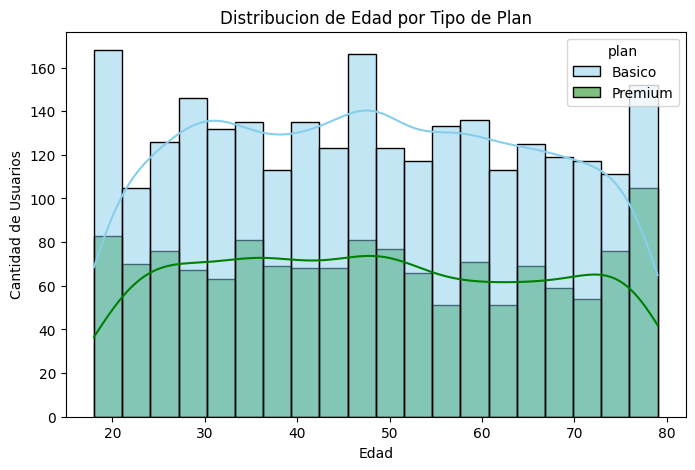

In [30]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True, bins=20)
plt.title('Distribucion de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución: Presenta distribucion relativamente simétrica en el rango de 18 a 80 años, sin picos pronunciados en un grupo etário específico. Y podemos ver claramente el hallazgo anterior que hay una relacion 2 a 1 con respecto a los planes, casi el doble de usuarios en el plan Básico (64.88%) y el plan Premium (35.12%)
- La edad no parece ser un factor determinante en la eleccion del tipo de plan, ya que ambos estan distribuidos de manera homogénea. 

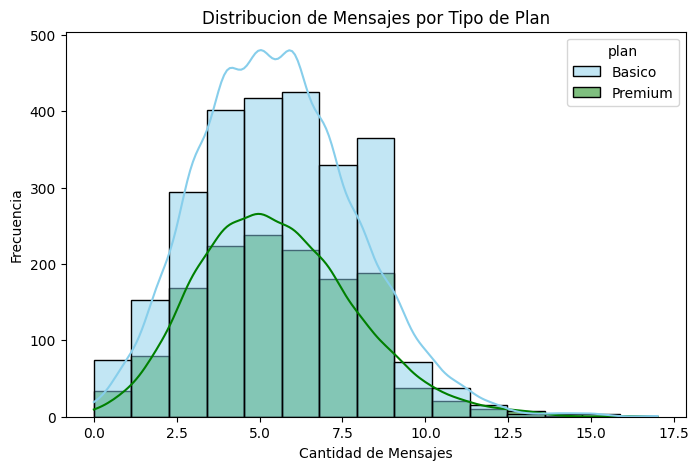

In [31]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='message_count', hue='plan', palette=['skyblue','green'], kde=True, bins=15)
plt.title('Distribucion de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- La distribuicon se presenta un poco asimétrica con un sesgo a la derecha (right-skewed) y un poco acampanada en el centro alrededor de los 3 y 6 mensajes.
- La curva del plan Básico es notoriamente mas alta (sobre 400) mientras que los usuarios del plan Premium siguen el mismo patron pero con un volumen menor, lo que tiene sentido teniendo en cuenta la relacion 2 a 1 mencionada anteriormente.
- Valores extremos: La mayoria de los usuarios envian entre 2 a 9 mensajes. Hay muy pocos que superen los 12 mensajes.

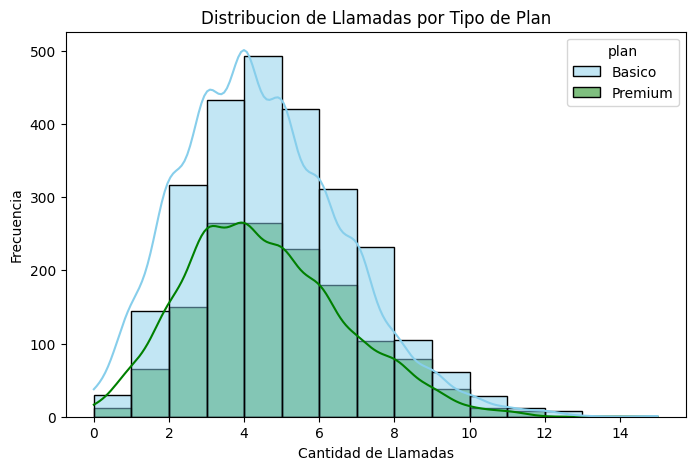

In [32]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='call_count', hue='plan', palette=['skyblue','green'], kde=True, bins=15)
plt.title('Distribucion de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución: Presenta una ligera asimetria hacia la derecha (right-skewed) acumulando la mayoria de datos entre las 3 y 6 llamadas.
- Comportamiento por plan: Muestran una tendencia similar de consumo. El plan Básico domina en volumen total, concentrando su pico entre las 4 y 5 llamadas mientras el plan Premium tiene su pico entre las 3 y 5 llamadas.
- La frecuencia de las llamadas no cambia significativamente según las suscripción, la diferencia en altura se debe principalmente a que hay más usuarios en el plan Básico.

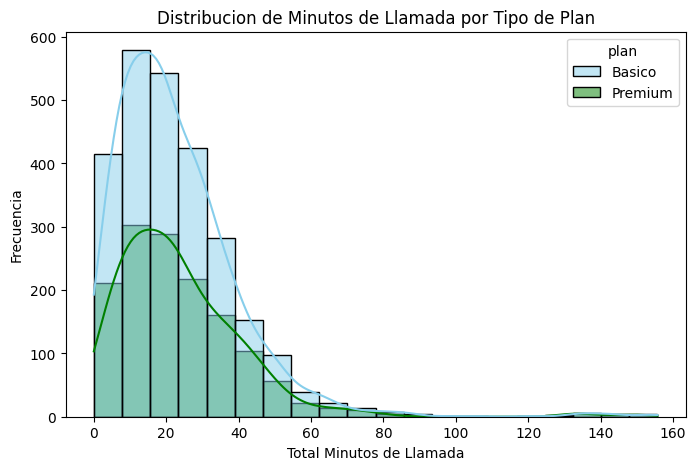

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='call_duration', hue='plan', palette=['skyblue','green'], kde=True, bins=20)
plt.title('Distribucion de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución: Aca se nota un claro sesgo a la derecha (right-skewed), con un pico fuerte en consumos bajos (entre 0 y 25 minutos) y una cola que se extiende hacia valores mas altos (150+ minutos)
- Comportamiento por plan: Los usuarios en ambos planes presentan la gran mayoria de sus llamadas en duraciones cortas. Sin embargo se observa en la cola de la derecha (60+ minutos) la presencia del plan Premium se vuelve un poco mas relevante con respecto al plan Básico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

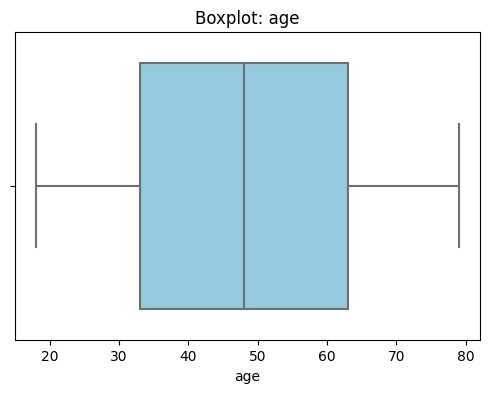

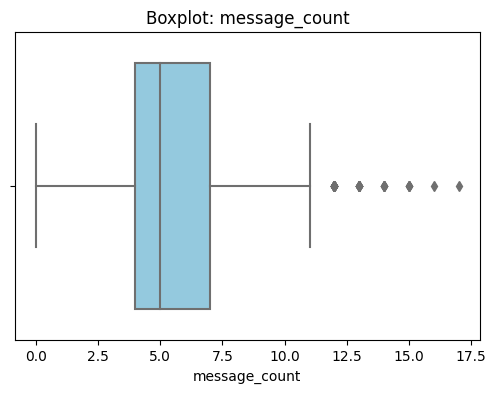

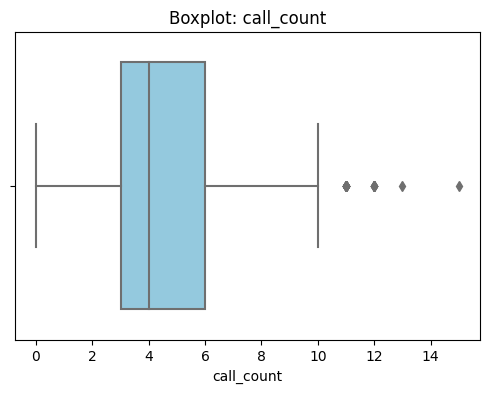

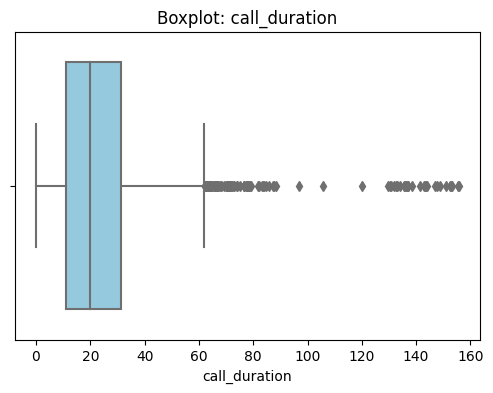

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'message_count', 'call_count', 'call_duration']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta Outliers, la distribución esta acotada entre los 18 y 80 años sin valores atípicos. 
- cant_mensajes: Presenta outliers superiores por encima del limite de la patilla superior (valores entre 12 y 17 mensajes).
- cant_llamadas: Presenta valores atípicos a la derecha (entre 11 y 15 llamadas).
- cant_minutos_llamada: Presenta una presencia marcada de outliers en la cola derecha a partir de los 60 minutos aproximadamente, alcanzando un maximo de 155 minutos. 

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['message_count', 'call_count', 'call_duration']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print (f'Límite superior para {col}: {limite_superior}')



Límite superior para message_count: 11.5
Límite superior para call_count: 10.5
Límite superior para call_duration: 61.870000000000005


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,message_count,call_count,call_duration
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener, el limite superior IQR es 11.5 y el maximo real es 17.0. Se decide mantener porque corresponden a comportamientos reales de uso de mensajeria. 
- cant_llamadas: Mantener, el limite superior IQR es 10.5 y el máximo real es 15.0. Se decide mantener ya que representan usuarios altamente activos (heavy users) sin ser errores de registro.
- cant_minutos_llamada: Mantener, el limite superior IQR es 61.87 minutos y el valor máximo alcanza 155.69 minutos. Es fundamental mantener estos datos porque eliminarlos alteraria el analisis real de consumo de tráfico y por consiguiente la estimación de ingresos por minuto. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
import numpy as np

condiciones_uso = [(user_profile['call_count'] < 5) & (user_profile['message_count'] < 5),
               (user_profile['call_count'] < 10) & (user_profile['message_count'] < 10)
              ]
elecciones_uso = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(condiciones_uso, elecciones_uso, default='Alto uso')

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,message_count,call_count,call_duration,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,Desconocido,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad

condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60 
]
elecciones_edad = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(condiciones_edad, elecciones_edad, default='Adulto Mayor')

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,message_count,call_count,call_duration,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,Desconocido,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

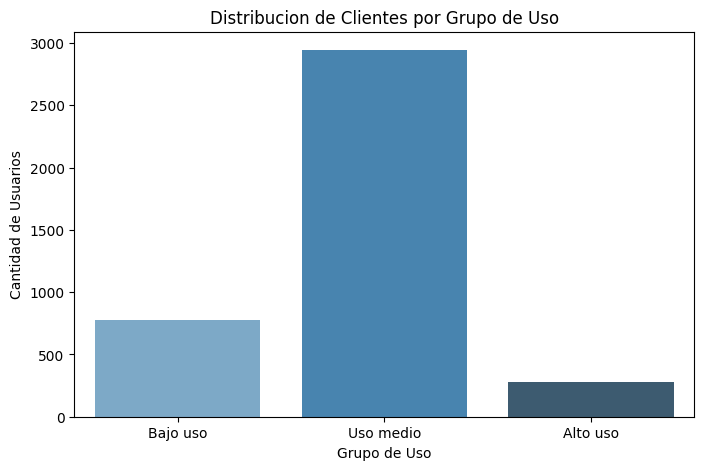

In [41]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso','Uso medio', 'Alto uso'], palette='Blues_d')
plt.title('Distribucion de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

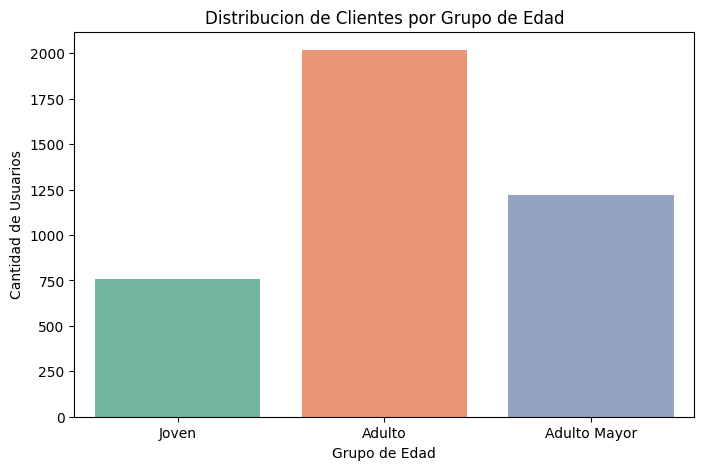

In [42]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='Set2')
plt.title('Distribucion de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
    
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**











### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**

- Originalmente se detectaron algunos datos con valores nulos enunciados a continuacion:

- **churn_date**: 3.534 valores nulos (88.35%) que significan usuarios que continuan activos en ConnectaTel.

- **city** 469 valores nulos (11.72%).

- **duration**: Fue detectado que estaba asociado con llamadas, 22.076 nulos (55.19%) debido a registros donde solo hubo actividad de mensajes.

- **length**: Fue detectado que estaba asociado con mensajes, 17.896 nulos (44.74%) debido a registros enfocados unicamente en tráfico de voz.


🔍 **Segmentos por Edad**

- **Por edad**: Se segmenta en tres categorias, Joven (<30 años, 750 usuarios), Adulto (30-59 años, 2000 usuarios) y Adulto Mayor(>=60, 1250 usuarios). El grupo de Adulto es dominante en el analisis.

📊 **Segmentos por Nivel de Uso**

- **Por Nivel de Uso**: Se definieron en tres categorias, Bajo uso (750 usuarios), Uso medio(Nucleo principal con >2750 usuarios) y Alto uso (400 usuarios). Con dominancia en el uso medio.


➡️ Esto sugiere que 

- El segmento más valioso por lo que representa para ConnectaTel es el de **Alto uso (heavy users)** en combinacion con el otro grupo etário de **Adultos**, ya que registraron el mayor volumen de tráfico entre llamadas extensas y alto consumo de mensajes, generando mayores ingresos marginales si superan los límites del plan Básico o justificando el cobro del plan Premium.
- - Se hallaron outliers atípicos hacia la derecha (right-skewed) en la duracion de llamadas (hasta 155 minutos, superando el límite IQR de 61.87 minutos) y en conteno de  mensajes (hasta 17 superando el límite IQR de 11.5). No deben eliminarse ya que reflejan un consumo real e intenso del servicio. Para el negocio implican una oportunidad para rentabilizar la red mediante migración de planes. 



💡 **Recomendaciones**

- **Upselling campaigns**: Lanzar campañas para migrar al usuario de Alto uso del plan Básico al plan Premium para maximizar el ARPU (ingreso promedio por usuario).

- Hay una **oportunidad** para crear un plan a la medida para la categoria Adultos que consumen un volumen de Uso medio, ofreciendo bolsas de minutos/mensajes adaptables a los hábitos de consumo.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`